# Chapter 95 — Midpoints and Interpolation

> **Prerequisites:** ch094 (Distance Between Points)
>
> **Outcomes:** Compute midpoints and weighted averages of points; Implement linear interpolation (lerp) between any two points; Understand interpolation as parameterized path traversal; Connect to animation, splines, and data imputation


## Midpoint and Weighted Average

The **midpoint** of two points P and Q is:
M = (P + Q) / 2 = ((x₁+x₂)/2, (y₁+y₂)/2)

The **weighted average** generalizes this:
W(t) = (1-t)·P + t·Q,  t ∈ [0, 1]

- t = 0: W = P
- t = 0.5: W = midpoint
- t = 1: W = Q
- t ∈ (0,1): W is between P and Q

This is **linear interpolation** (lerp). As t sweeps 0→1, W traces the line segment from P to Q.

**Extrapolation:** If t < 0 or t > 1, W falls outside the segment.
This is valid mathematically but may not be physically meaningful.

*(This is the same "parameterized path" idea as parametric curves in ch107.)*

C:\Users\user\AppData\Local\Temp\ipykernel_26608\3300307872.py:31: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8712 (\N{ELEMENT OF}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


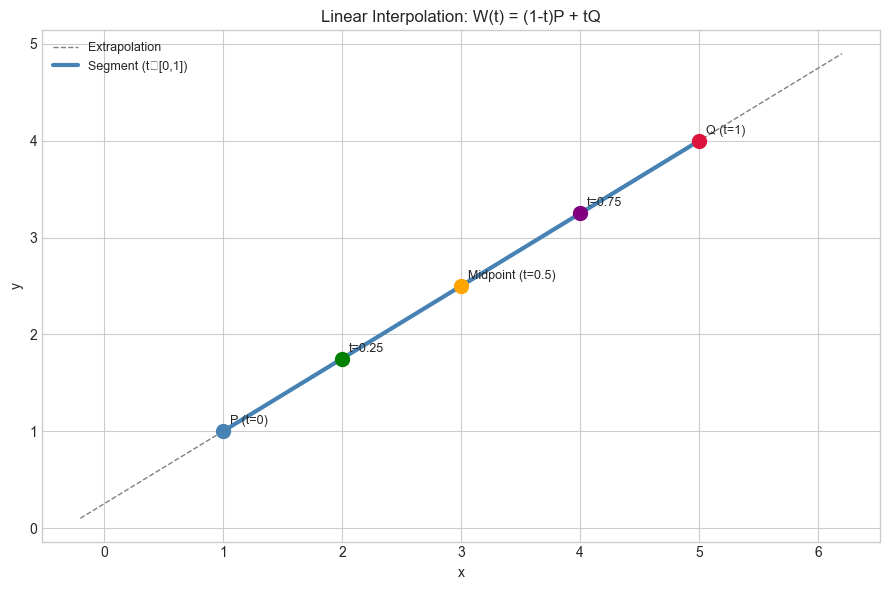

In [1]:
# --- Interpolation visualization ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

def lerp(P, Q, t):
    """Linear interpolation: (1-t)*P + t*Q."""
    return (1 - t) * np.asarray(P) + t * np.asarray(Q)

P = np.array([1.0, 1.0])
Q = np.array([5.0, 4.0])

t_vals = np.linspace(-0.3, 1.3, 200)
path = np.array([lerp(P, Q, t) for t in t_vals])

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(path[:,0], path[:,1], color='gray', linewidth=1, linestyle='--', label='Extrapolation')

t_seg = np.linspace(0, 1, 100)
seg = np.array([lerp(P, Q, t) for t in t_seg])
ax.plot(seg[:,0], seg[:,1], color='steelblue', linewidth=3, label='Segment (t∈[0,1])')

for t, color, label in [(0,'steelblue','P (t=0)'), (0.25,'green','t=0.25'), (0.5,'orange','Midpoint (t=0.5)'),
                         (0.75,'purple','t=0.75'), (1.0,'crimson','Q (t=1)')]:
    pt = lerp(P, Q, t)
    ax.plot(*pt, 'o', color=color, markersize=10, zorder=5)
    ax.annotate(label, pt, xytext=(5,5), textcoords='offset points', fontsize=9)

ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Linear Interpolation: W(t) = (1-t)P + tQ'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

## Multi-Point Interpolation



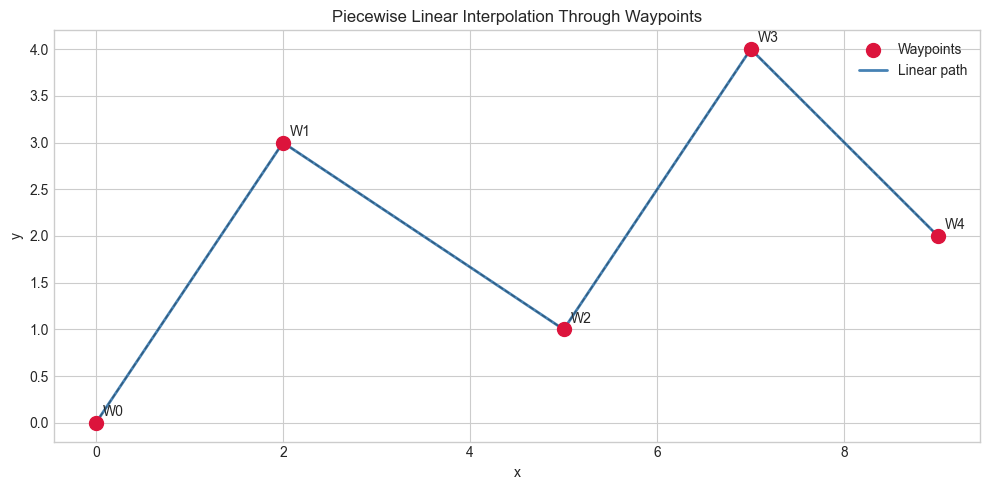

Total path length: 13.59085258013351


In [2]:
# --- Interpolation along a path through multiple points ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

def lerp_path(waypoints, n_samples=200):
    """Linearly interpolate through a sequence of waypoints."""
    pts = np.array(waypoints)
    n = len(pts)
    # Parameter t: uniform from 0 to n-1
    t_vals = np.linspace(0, n-1, n_samples)
    result = []
    for t in t_vals:
        i = int(t)
        frac = t - i
        if i >= n-1:
            result.append(pts[-1])
        else:
            result.append(lerp(pts[i], pts[i+1], frac))
    return np.array(result)

waypoints = [(0,0),(2,3),(5,1),(7,4),(9,2)]
path = lerp_path(waypoints)

fig, ax = plt.subplots(figsize=(10, 5))
wp = np.array(waypoints)
ax.scatter(wp[:,0], wp[:,1], s=100, color='crimson', zorder=5, label='Waypoints')
for i, (x,y) in enumerate(waypoints):
    ax.annotate(f'W{i}', (x,y), xytext=(5,5), textcoords='offset points', fontsize=10)
ax.plot(path[:,0], path[:,1], color='steelblue', linewidth=2, label='Linear path')
ax.plot(wp[:,0], wp[:,1], 'k--', linewidth=1, alpha=0.3)
ax.set_title('Piecewise Linear Interpolation Through Waypoints')
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.legend()
plt.tight_layout(); plt.show()

print("Total path length:", sum(np.linalg.norm(path[i+1]-path[i]) for i in range(len(path)-1)))

## Applications

- **Animation:** lerp from start pose to end pose over n_frames → smooth transition
- **Color blending:** lerp(rgb_start, rgb_end, t) → gradient
- **Data imputation:** missing value at time t → lerp between flanking observed values
- **Bézier curves (ch116):** recursive lerp generates smooth curves through control points
- **Texture mapping in graphics:** bilinear interpolation = lerp in 2 dimensions

## Exercises

**Easy 1.** Find the midpoint of (2, 5) and (8, 1). Then find the point 1/3 of the way from P to Q.

**Easy 2.** Implement `lerp_color(c1, c2, t)` for RGB tuples. Blend red (255,0,0) and blue (0,0,255) at t=0, 0.25, 0.5, 0.75, 1.0.

**Medium 1.** Given GPS coordinates (lat, lon), lerp 10 interpolated points between two cities. *(Assume flat Earth for simplicity.)*

**Medium 2.** Implement bilinear interpolation for a 2D grid: given a 2D array of values and a fractional (i, j) index, return the interpolated value using lerp in both dimensions.

**Hard.** Implement smooth step interpolation: smoothstep(t) = 3t² - 2t³. Compare lerp vs smoothstep animation (plot both over 100 frames). Smoothstep has zero derivative at t=0 and t=1 — why does this matter for animation?

## Summary

- Midpoint: M = (P+Q)/2; weighted average: W(t) = (1-t)P + tQ
- lerp traces the line segment from P to Q as t goes 0→1
- Piecewise linear interpolation connects waypoints with straight segments
- This is the foundation for Bézier curves, splines, and animation

**Forward connections:**
- ch107 (Parametric Curves): lerp with t parameterizes all curves
- ch116 (Bézier Curves): recursive lerp → smooth curves
- ch285 (Regression): imputation strategies use interpolation